# Quadcopter Cascade PID — Figure-8 Trajectory Tracking

This notebook presents a three-loop cascade PID simulation of a quadcopter tracking a figure-8 ($\infty$) trajectory. It models the vehicle dynamics, builds the control hierarchy, and runs the simulation using [c4dynamics](https://c4dynamics.github.io/c4dynamics/).

The quadcopter, its state, and all stored histories are represented by a `c4d.rigidbody` object. The main loop runs inline — every step is visible and readable.

---

## Simulation Overview

The process begins with initial conditions, where the vehicle, trajectory, and controllers are set up.

The simulation then enters a **main loop** at a timestep of 5 ms (200 Hz) until the flight ends. Each iteration:

1. **Reference** — get the target position and velocity at the current time
2. **Outer loop (50 Hz)** — position error -> desired angles + thrust command
3. **Middle loop (100 Hz)** — angle error -> desired body rates
4. **Inner loop (200 Hz)** — rate error -> torque commands
5. **Control allocation** — thrust + torques -> rotor speeds
6. **Integration** — advance the vehicle state one timestep via RK4
7. **Store** — `quad.store(t)` logs the full state; `quad.storeparams(...)` logs control inputs

After the loop, `plot_results()` shows trajectories and angles using `quad.data()`. `compute_metrics()` reports RMSE over the figure-8 phase.

The implementation classes are in `quad_pid_utils.py`. The notebook contains the loop.

---

The program uses the following c4dynamics components:

| Object | Module | Description |
|--------|--------|-------------|
| `quad` | `rigidbody` | The quadcopter — state, integration, storage, and retrieval |
| `g_ms2` | `const` | Gravity constant [m/s²] |
| `r2d` | `const` | Radians to degrees conversion |
| `plotdefaults` | `utils` | Default axis formatting for matplotlib |

In addition:
- `quad.store(t)` logs the full 12-state vector at every timestep
- `quad.storeparams(...)` logs control inputs (thrust, torques)
- `quad.data('x')`, `quad.data('phi', c4d.r2d)` retrieve stored histories for plotting and metrics

The dynamics function and controller classes use `quad.X`, `quad.phi`, `quad.vx`, etc. to read the current state directly from the object.

---
## 1. Setup

In [ ]:
import sys
if 'google.colab' in sys.modules:
    !pip install c4dynamics -q

import numpy as np
import c4dynamics as c4d
from quad_pid_utils import (dynamics, get_reference, get_reference_velocity,
                             OuterPositionPID, MiddleAttitudePID, InnerRatePID,
                             ControlAllocator, plot_results, compute_metrics)

### Time

In [ ]:
t   = 0.0
dt  = 5e-3    # master timestep [s] = inner loop (200 Hz)
tf  = 90.0    # simulation end time [s]

---
## 2. Vehicle

The quadcopter is modeled as a `c4d.rigidbody` — a 12-state rigid body object with position, velocity, Euler angles, and body angular rates.

$$\mathbf{X} = [x,\ y,\ z,\ v_x,\ v_y,\ v_z,\ \varphi,\ \theta,\ \psi,\ p,\ q,\ r]^T$$


The four control inputs are:

$$\mathbf{U} = [F,\ \tau_\varphi,\ \tau_\theta,\ \tau_\psi]^T$$


For the full theoretical background on rigid-body kinematics and the state representation used by c4dynamics, see the [c4dynamics kinematics page](https://c4dynamics.github.io/c4dynamics/concepts/kinematics.html).

The vehicle starts on the ground stationary level. The `quad` object initializes the state, stores every sample during the simulation, and provides history retrieval for plotting and metrics via `quad.data()`.



### Physical parameters

In [ ]:
vehicle = {
    'm'  : 0.468,      # mass [kg]
    'g'  : 9.81,       # gravity [m/s^2]
    'l'  : 0.225,      # arm length — center to motor [m]
    'kT' : 2.98e-6,    # thrust coefficient  [N/(rad/s)^2]
    'kQ' : 0.0382,     # torque coefficient  [N.m/(rad/s)^2]
    'Ixx': 4.856e-3,   # roll  inertia [kg.m^2]
    'Iyy': 4.856e-3,   # pitch inertia [kg.m^2]
    'Izz': 8.801e-3,   # yaw   inertia [kg.m^2]
    'Ax' : 0.30,       # aero drag — x
    'Ay' : 0.30,       # aero drag — y
    'Az' : 0.25,       # aero drag — z
    'Ar' : 0.20,       # rotational drag — angular rates
    'IR' : 3.357e-5,   # rotor inertia [kg.m^2]
}

# Initialize the rigidbody — quadcopter starts at rest on the ground
quad      = c4d.rigidbody()
quad.mass = vehicle['m']
quad.I    = [vehicle['Ixx'], vehicle['Iyy'], vehicle['Izz']]

# Control inputs stored alongside state
quad.F         = vehicle['m'] * vehicle['g']   # thrust [N]  — initialized to hover
quad.tau_phi   = 0.0                           # roll  torque [N.m]
quad.tau_theta = 0.0                           # pitch torque [N.m]
quad.tau_psi   = 0.0                           # yaw   torque [N.m]

---
## 3. Trajectory

The reference is a **Lissajous figure-8** in the horizontal plane at a fixed altitude:

$$x_{ref}(t) = A \cdot \sin(\omega \cdot \tau), \qquad y_{ref}(t) = B \cdot \sin(2\omega \cdot \tau), \qquad z_{ref}(t) = z_{ref}$$

where $\tau = t - t_{takeoff}$ is the time since the figure-8 phase started.

This is a standard benchmark for trajectory tracking controllers because it combines simultaneous motion in both horizontal axes, continuous direction reversals, and a non-trivial curvature profile — all of which stress-test the controller's ability to reject coupling errors and follow a dynamic reference.


### Parameter Meanings

| Parameter | Physical meaning |
|-----------|------------------|
| `A` | Half-width of the figure-8 in the X direction [m]. Larger values mean a wider trajectory. |
| `B` | Half-width in the Y direction [m]. Controls the "height" of each lobe of the figure-8. |
| `omega` | Angular frequency [rad/s]. Controls how fast the quadcopter flies the path. Period = $2\pi/\omega$. |
| `z_ref` | Constant hover altitude [m]. The vehicle holds this height throughout the maneuver. |



#####The full flight has three phases:

| Phase | Duration | Description |
|-------|----------|-------------|
| **Takeoff** | 0 — 8 s | Z rises from 0 to `z_ref` on a smooth S-curve |
| **Figure-8** | 8 s — `t_end - 8 s` | X/Y track the Lissajous at constant altitude |
| **Landing** | last 8 s | X/Y return to origin, Z descends to 0 |

`get_reference(t, ...)` and `get_reference_velocity(t, ...)` return the instantaneous reference position and velocity at any time `t`.

In [ ]:
trajectory = {
    'A'    : 4.0,    # figure-8 X amplitude [m]
    'B'    : 2.0,    # figure-8 Y amplitude [m]
    'omega': 0.1,    # angular frequency [rad/s]  (period ~ 62.8 s)
    'z_ref': 1.5,    # hover altitude [m]
    't_end': 90.0,   # total simulation time [s]
}

A, B, omega, z_ref = trajectory['A'], trajectory['B'], trajectory['omega'], trajectory['z_ref']

---
## 4. Cascade PID Control

### Why Cascade PID?

A quadcopter is **underactuated** — 6 degrees of freedom, only 4 control inputs. To move horizontally the vehicle must tilt, which means position and attitude are tightly coupled. A single PID loop cannot handle this. The cascade structure separates the problem by bandwidth:

| Loop | Rate | Input | Output |
|------|------|-------|--------|
| **Outer** — Position | 50 Hz | Position error $(x, y, z)$ | Desired angles $\varphi_d, \theta_d$ + thrust $F$ |
| **Middle** — Attitude | 100 Hz | Angle error $(\varphi, \theta, \psi)$ | Desired body rates $(p_d, q_d, r_d)$ |
| **Inner** — Rate | 200 Hz | Rate error $(p, q, r)$ | Torques $(\tau_\varphi, \tau_\theta, \tau_\psi)$ |

**Tuning order:** always tune inner first, then middle, then outer. Each loop must be stable before the next loop is closed around it.

### Control Law

Each controller implements:

$$u = K_p \cdot e + K_i \cdot \int e\, dt - K_d \cdot \dot{m}$$

The derivative acts on the **measurement** $\dot{m}$, not on the error — this eliminates derivative kick when the setpoint changes. All integrators include anti-windup clamping. The outer loop adds a **velocity feedforward** term to reduce phase lag on curved trajectories.

In [ ]:
controller = {

    # Inner loop — angular rate (200 Hz)
    'Kp_p': 0.80,  'Ki_p': 0.0001,  'Kd_p': 0.010,
    'Kp_q': 0.80,  'Ki_q': 0.0001,  'Kd_q': 0.010,
    'Kp_r': 0.60,  'Ki_r': 0.0001,  'Kd_r': 0.008,

    # Middle loop — attitude (100 Hz)
    'Kp_phi'  : 6.0,  'Ki_phi'  : 0.0001,  'Kd_phi'  : 0.80,  'AW_phi'  : 0.5,
    'Kp_theta': 6.0,  'Ki_theta': 0.0001,  'Kd_theta': 0.80,  'AW_theta': 0.5,
    'Kp_psi'  : 4.0,  'Ki_psi'  : 0.5,     'Kd_psi'  : 0.40,  'AW_psi'  : 0.5,

    # Outer loop — position (50 Hz)
    'Kp_x': 0.80,  'Ki_x': 0.00,  'Kd_x': 0.50,  'AW_x': 0.5,
    'Kp_y': 1.00,  'Ki_y': 0.00,  'Kd_y': 0.70,  'AW_y': 0.5,
    'Kp_z': 10.0,  'Ki_z': 10.0,  'Kd_z': 1.50,  'AW_z': 3.0,

    # Velocity feedforward
    'Kff_x': 0.35,  'Kff_y': 0.40,

    # Limits
    'N_rate'        : 50,       # Filter coefficient for derivative term in rate controller
    'omega_max'     : 1000.0,   # max rotor speed [rad/s]
    'T_max_factor'  : 4,        # max thrust factor: T_max = T_max_factor * K_thrust * omega_max**2	[N]
    'T_min'         : 0.0,      # min thrust [N]
    'att_cmd_limit' : 0.314,    # Max attitude command [rad] = 18deg
    'yaw_rate_limit': 1.0,      # Max yaw rate command [rad/s]
}

# Instantiate controllers
outer_ctrl = OuterPositionPID(controller, vehicle['m'], vehicle['g'], vehicle['kT'])
mid_ctrl   = MiddleAttitudePID(controller)
inner_ctrl = InnerRatePID(controller,
                           vehicle['Ixx'], vehicle['Iyy'], vehicle['Izz'],
                           vehicle['l'],   vehicle['kT'])
allocator  = ControlAllocator(vehicle['kT'], vehicle['kQ'], vehicle['l'],
                               controller['omega_max'])

---
## 5. Dynamics

The quadcopter is modeled by the full **nonlinear Newton-Euler equations** — no linearization.

**Translational dynamics** (inertial frame):

$$m \ddot{\mathbf{r}} = \mathbf{F}_{thrust} + \mathbf{F}_{drag} + \mathbf{F}_{gravity}$$

The thrust $F$ acts along $-Z_b$ and is projected to the inertial frame via the ZYX rotation matrix.

**Rotational dynamics** (Euler's equations in body frame):

$$\mathbf{I}\dot{\boldsymbol{\omega}} + \boldsymbol{\omega} \times \mathbf{I}\boldsymbol{\omega} = \boldsymbol{\tau}$$

where $\boldsymbol{\tau} = [\tau_\varphi,\ \tau_\theta,\ \tau_\psi]^T$ are the torques from differential rotor thrust. A gyroscopic coupling term from rotor angular momentum is included.

The `dynamics(quad, rotor_speeds, vehicle)` function computes the 12 state derivatives at each RK4 substep. Integration is carried out by a hand-written RK4 that updates `quad.X` directly.

---
## 6. Control Allocation

The four control inputs $[F, \tau_\varphi, \tau_\theta, \tau_\psi]$ are mapped to individual rotor speeds by inverting the thrust-torque mixing matrix:

$$\begin{bmatrix} \Omega_1^2 \\ \Omega_2^2 \\ \Omega_3^2 \\ \Omega_4^2 \end{bmatrix} = \mathbf{\Gamma}^{-1} \begin{bmatrix} F \\ \tau_\varphi \\ \tau_\theta \\ \tau_\psi \end{bmatrix}$$

Motor layout — plus (+) configuration, viewed from above:


`ControlAllocator.allocate()` clamps $\Omega_i^2 \geq 0$ (rotors cannot pull) and $\Omega_i \leq \Omega_{max}$ before taking the square root.

---
## 7. Main Loop

The simulation loop advances the quadcopter state from `t = 0` to `t = tf`.

At each timestep the three cascade loops fire at their respective rates:
the outer position loop every 4 steps (50 Hz), the middle attitude loop every 2 steps (100 Hz), and the inner rate loop every step (200 Hz).

`quad.store(t)` logs the full state vector. `quad.storeparams(...)` logs the control inputs. After the loop, all histories are available via `quad.data()`.

In [ ]:
# Loop rate counters
Ts_outer  = 1.0 / 50.0    # 0.020 s
Ts_middle = 1.0 / 100.0   # 0.010 s
outer_time = middle_time = 0.0

# Initial setpoints
psi_d   = 0.0   # desired yaw — fixed
phi_d   = theta_d = 0.0
p_d     = q_d = r_d = 0.0
T_cmd   = vehicle['m'] * vehicle['g']   # start at hover thrust
rotor_speeds = np.array([np.sqrt(T_cmd / (4 * vehicle['kT']))] * 4)

print(f'Simulation start  |  tf = {tf} s  |  dt = {dt} s')

while t <= tf:

    # ── Reference at current time ──
    xd, yd, zd       = get_reference(t, A, B, omega, z_ref)
    vxd_ff, vyd_ff   = get_reference_velocity(t, A, B, omega)

    # ── Outer loop — Position  (50 Hz) ──
    outer_time += dt
    if outer_time >= Ts_outer:
        T_cmd, phi_d, theta_d, psi_d = outer_ctrl.compute(
            xd, yd, zd, psi_d, quad, Ts_outer)
        quad.F = T_cmd
        outer_time = 0.0

    # ── Middle loop — Attitude  (100 Hz) ──
    middle_time += dt
    if middle_time >= Ts_middle:
        p_d, q_d, r_d = mid_ctrl.compute(phi_d, theta_d, psi_d, quad, Ts_middle)
        middle_time = 0.0

    # ── Inner loop — Rate  (200 Hz, every step) ──
    quad.tau_phi, quad.tau_theta, quad.tau_psi = inner_ctrl.compute(
        p_d, q_d, r_d, quad, dt)

    # ── Control allocation — torques to rotor speeds ──
    rotor_speeds = np.array(allocator.allocate(
        quad.F, quad.tau_phi, quad.tau_theta, quad.tau_psi))

    # ── Integrate dynamics — RK4 ──
    k1 = dynamics(quad, rotor_speeds, vehicle)
    quad.X += 0.5*dt*k1;  k2 = dynamics(quad, rotor_speeds, vehicle)
    quad.X -= 0.5*dt*k1;  quad.X += 0.5*dt*k2
    k3 = dynamics(quad, rotor_speeds, vehicle)
    quad.X -= 0.5*dt*k2;  quad.X += dt*k3
    k4 = dynamics(quad, rotor_speeds, vehicle)
    quad.X -= dt*k3
    quad.X += (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

    # ── Store state and control inputs ──
    t += dt
    quad.store(t)
    quad.storeparams(['F', 'tau_phi', 'tau_theta', 'tau_psi'], t=t)

print('Simulation complete.')

Simulation start  |  tf = 90.0 s  |  dt = 0.005 s
Simulation complete.


---
## 8. Results

### What to Expect

A well-tuned cascade PID on this trajectory should show:

- **Position** — X and Y closely follow the sinusoidal references. Small amplitude and phase lag are normal.
- **Altitude** — Z rises sharply during takeoff, holds `z_ref` with very small deviation, and descends smoothly.
- **Euler angles** — roll and pitch stay within ±15°. Yaw remains near zero.
- **3D trajectory** — a clean takeoff lobe, the figure-8 loops, and a straight descent to origin.

All plots are generated from `quad.data()` — the stored histories in the `rigidbody` object.

### Trajectories and Angles

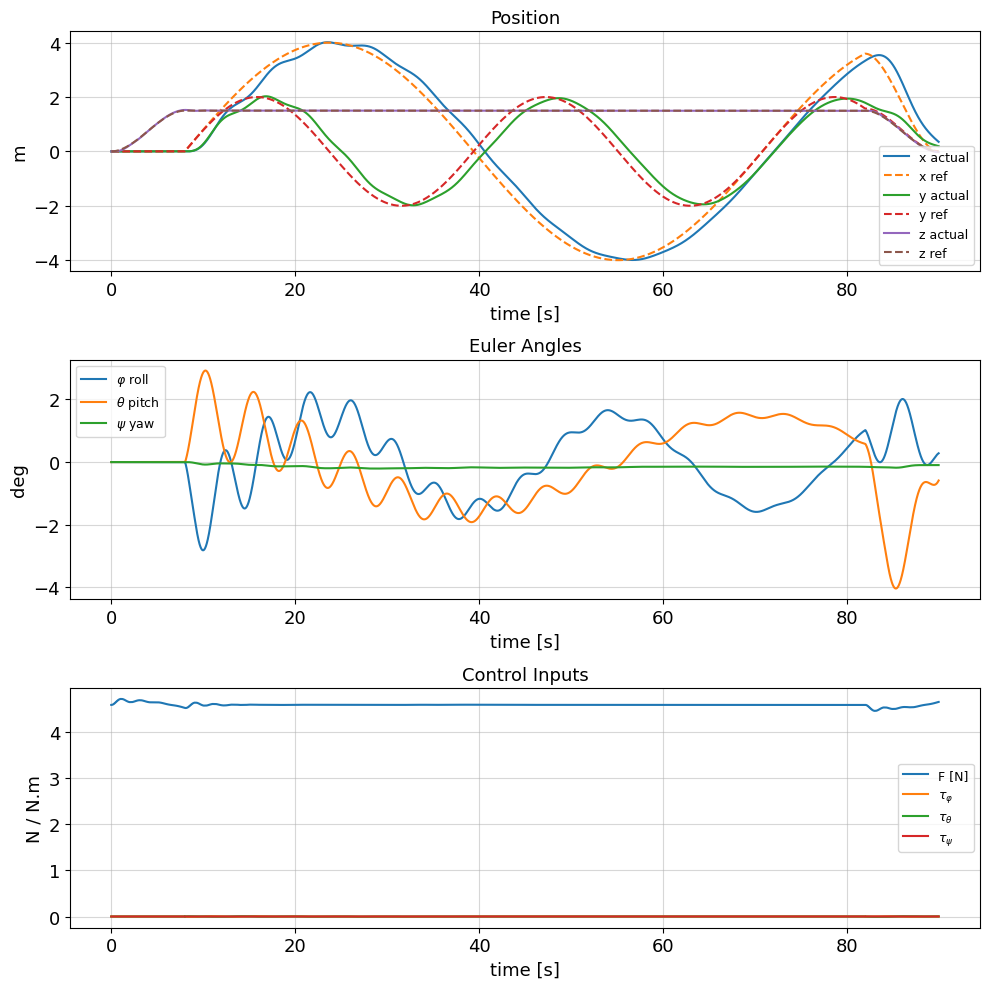

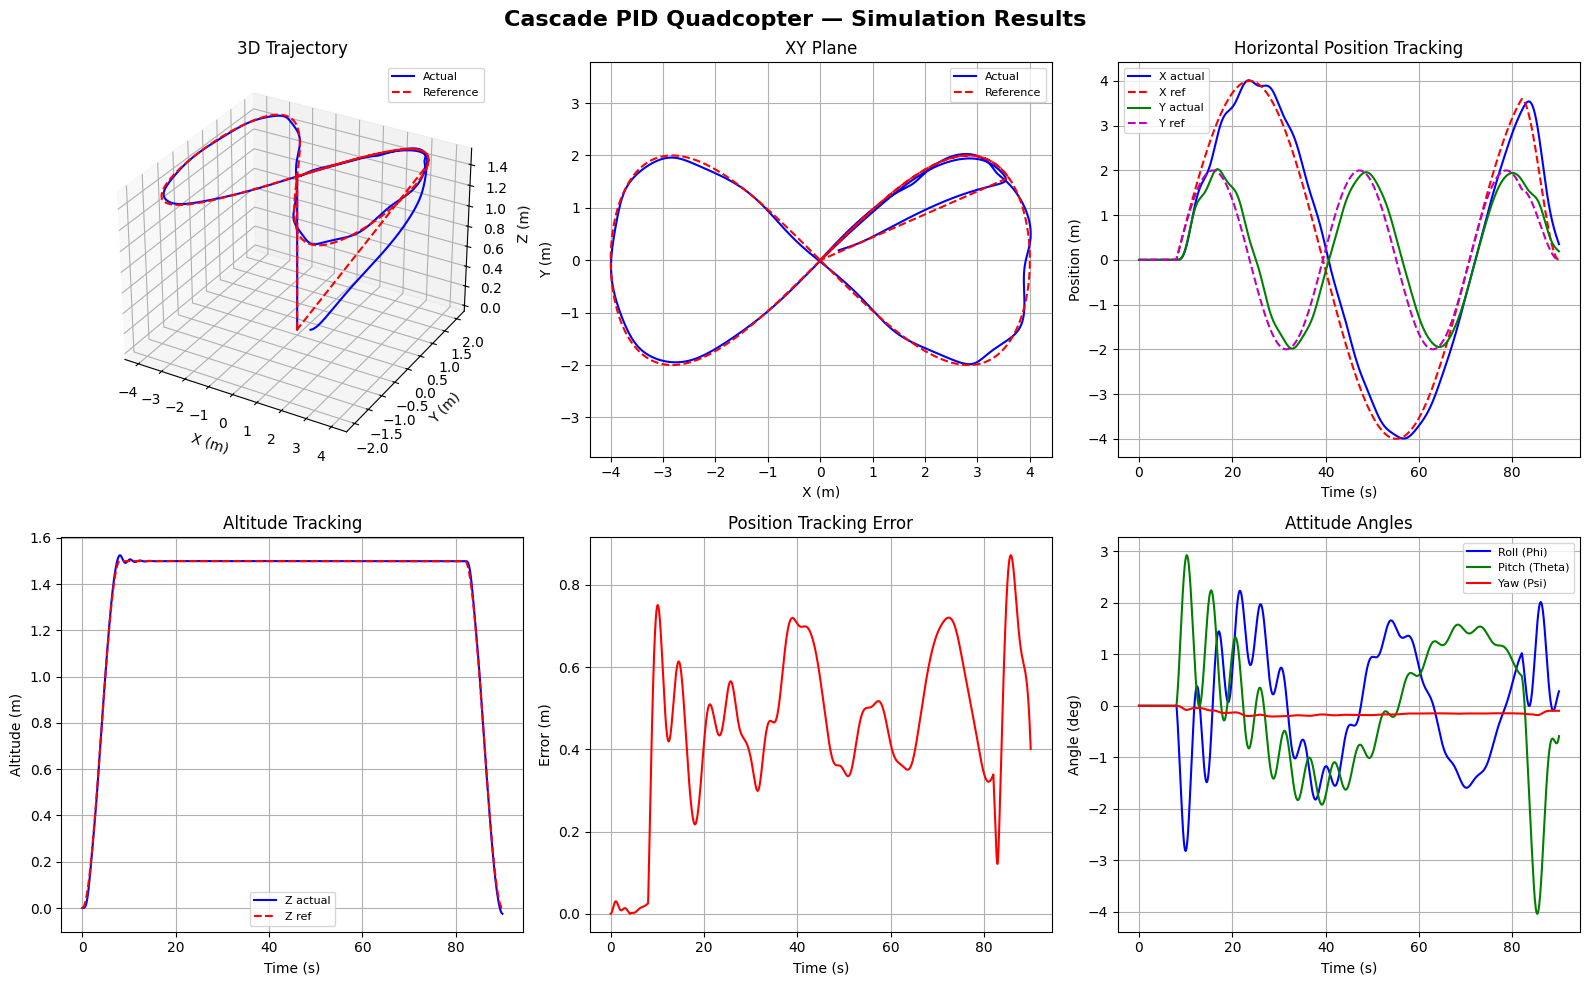

In [ ]:
plot_results(quad, trajectory)

### Tracking Metrics

`compute_metrics()` computes RMSE for X, Y, Z tracking over the **figure-8 phase only. Normalized RMSE expresses tracking error as a percentage of trajectory amplitude.

| Normalized RMSE | Interpretation |
|-----------------|----------------|
| < 5% | Excellent |
| 5 – 15% | Acceptable |
| > 15% | Retune from inner loop, or reduce `omega` |

In [ ]:
metrics = compute_metrics(quad, trajectory)

   TRACKING PERFORMANCE METRICS
  RMSE x : 0.3627 m  (9.1% of X amplitude)
  RMSE y : 0.3571 m  (17.9% of Y amplitude)
  RMSE z : 0.002108 m  (0.141% of altitude)
  Max altitude deviation : 2.53 cm
